In [ ]:
from pathlib import Path
import importlib
import math
import sys

import numpy as np
import pandas as pd

from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "proposal_new.tex").exists():
    candidate = NOTEBOOK_DIR / "course_project"
    if (candidate / "proposal_new.tex").exists():
        NOTEBOOK_DIR = candidate

sys.path.insert(0, str(NOTEBOOK_DIR))

import conformal_utils
importlib.reload(conformal_utils)

from conformal_utils import (
    calibrate_selective_threshold,
    evaluate_selective_threshold,
    load_results,
    build_prompt_table_for_baseline
)

DATA_ROOT = NOTEBOOK_DIR / "data" / "when_to_generate"
MAIN_RUN_DIR = DATA_ROOT / "run_k10_3000"


## Configuration

We set up the main parameters, including the baseline score used by the image generative model to rank candidate images and select the highest-scoring one, and the ground-truth score used to define the label. The overall goal is for the model to output images that are well aligned with the ground-truth score.

For each prompt, the ground-truth set among the generated images is defined as the top $K=3$ images ranked by the ground-truth score. Specifically, `GROUND_TRUTH_SCORE` defines the labels: for each prompt, the selected baseline image is labeled as correct if and only if it falls within the top `LABEL_TOP_K` images according to the ground-truth score.



In [2]:
# --- score source mapping ---
SCORE_KEY_MAP = {
    "image_reward": "image_reward_scores",
    "pickapick": "pickscore_scores",
    "pickscore": "pickscore_scores",
    "clip": "self_clip_scores",
    "self_clip": "self_clip_scores",
    "latent_norm": "latent_norms",
}

# --- score direction for ranking ("higher" means larger is better) ---
SCORE_PREFERENCE = {
    "image_reward": "higher",
    "pickapick": "higher",
    "pickscore": "higher",
    "clip": "higher",
    "self_clip": "higher",
    "latent_norm": "higher",  # set to "lower" if you want smaller latent norm to be preferred
}

BASELINE_SCORES_method = 'image_reward'
GROUND_TRUTH_SCORE = "pickapick"
BASELINE_SCORES = [BASELINE_SCORES_method]  # compare these against the ground truth
LABEL_TOP_K = 3

SCORE_COLUMNS_FOR_CONFORMAL = [
    "selected_score_raw",
    "selected_score_minmax",
    "selected_score_zscore",
    "selected_score_margin",
    "selected_score_softmax",
]
SOFTMAX_TEMPERATURE = 1.0
MINMAX_FIXED_EPSILON = 0.10


# --- naive threshold-baseline config (for baselines 1-5) ---
NAIVE_BASELINE_SCORE = BASELINE_SCORES_method
NAIVE_SELECTION_CRITERION = "accuracy_at_min_acceptance"  # one of: accuracy_at_min_acceptance, utility, f1_balance
NAIVE_MIN_ACCEPTANCE_RATE = 0.25
NAIVE_UTILITY_LAMBDA = 0.10  # only used for "utility"


In [3]:
def load_run_records(run_dir: Path) -> tuple[list[dict], Path]:
    candidate_paths = [
        run_dir / "results.json",
        run_dir / "results.jsonl",
    ]
    for path in candidate_paths:
        if path.exists():
            return load_results(path), path
    raise FileNotFoundError(f"Could not find results file in {run_dir}")

#### we have 3000 prompt-image pairs, and for each pair we have 10 generations, so we expect 30000 records in total
main_records, loaded_path = load_run_records(MAIN_RUN_DIR)
print(f"Loaded records: {len(main_records)} from {loaded_path}")
print("Sample keys:", sorted(main_records[0].keys()))


Loaded records: 3000 from /Users/mzheng/Desktop/research/course/10723/course_project/data/when_to_generate/run_k10_3000/results.json
Sample keys: ['K', 'generation_time_sec', 'image_paths', 'image_reward_rankings', 'image_reward_scores', 'latent_norms', 'pickscore_scores', 'prompt', 'prompt_idx', 'scoring_time_sec', 'seed', 'self_clip_scores', 'top1_idx', 'top1_image_reward', 'top1_latent_norm', 'top1_pickscore', 'top1_self_clip']


In [4]:
baseline_prompt_tables = {}
for baseline_score in BASELINE_SCORES:
    baseline_prompt_tables[baseline_score] = build_prompt_table_for_baseline(
        main_records,
        MAIN_RUN_DIR,
        baseline_score=baseline_score,
        ground_truth_score=GROUND_TRUTH_SCORE,
        label_top_k=LABEL_TOP_K,
        softmax_temperature=SOFTMAX_TEMPERATURE,
        minmax_fixed_epsilon=MINMAX_FIXED_EPSILON,
    )

baseline_overall_rows = []
for baseline_score, prompt_df in baseline_prompt_tables.items():
    baseline_overall_rows.append(
        {
            "baseline_score": baseline_score,
            "ground_truth_score": GROUND_TRUTH_SCORE,
            "num_prompts": len(prompt_df),
            "always_accept_accuracy": prompt_df["selected_label"].mean(),
            "always_accept_error": 1.0 - prompt_df["selected_label"].mean(),
        }
    )

baseline_overall_table = pd.DataFrame(baseline_overall_rows).sort_values("baseline_score")
display(baseline_overall_table)


,baseline_score,ground_truth_score,num_prompts,always_accept_accuracy,always_accept_error
0,image_reward,pickapick,3000,0.488,0.512


## Data Split for conformal calibration and testing

In [5]:

CALIBRATION_FRACTION = 0.8
SPLIT_SEED = 1

if not baseline_prompt_tables:
    raise ValueError("No baseline tables were built.")

any_table = next(iter(baseline_prompt_tables.values()))
n_prompts = len(any_table)
rng = np.random.default_rng(SPLIT_SEED)
permutation = rng.permutation(n_prompts)
calibration_size = int(round(n_prompts * CALIBRATION_FRACTION))
calibration_idx = np.sort(permutation[:calibration_size])
test_idx = np.sort(permutation[calibration_size:])

split_summary = pd.DataFrame(
    [
        {"split": "calibration", "num_prompts": int(len(calibration_idx))},
        {"split": "test", "num_prompts": int(len(test_idx))},
    ]
)
display(split_summary)


,split,num_prompts
0,calibration,2400
1,test,600


## Conformal Calibration and baselines results at Alpha and Delta, with differen concertration bound 


In [6]:
ALPHA = 0.50

DELTA = 0.1
TARGET_SCORE_COLUMN = "selected_score_softmax"
BOUND_TYPES = ["hoeffding", "clopper_pearson", "kl_binomial"]

experiment_rows = []

for baseline_score, prompt_df in baseline_prompt_tables.items():
    cal_df = prompt_df.iloc[calibration_idx].reset_index(drop=True)
    test_df = prompt_df.iloc[test_idx].reset_index(drop=True)

    if TARGET_SCORE_COLUMN not in prompt_df.columns:
        continue

    cal_scores = cal_df[TARGET_SCORE_COLUMN].to_numpy(dtype=float)
    cal_labels = cal_df["selected_label"].to_numpy(dtype=int)
    test_scores = test_df[TARGET_SCORE_COLUMN].to_numpy(dtype=float)
    test_labels = test_df["selected_label"].to_numpy(dtype=int)

    always_accept_test = evaluate_selective_threshold(
        test_scores,
        test_labels,
        -np.inf,
    )

    for bound_type in BOUND_TYPES:
        cal_result = calibrate_selective_threshold(
            cal_scores,
            cal_labels,
            alpha=ALPHA,
            delta=DELTA,
            bound_type=bound_type,
        )
        test_metrics = evaluate_selective_threshold(
            test_scores,
            test_labels,
            cal_result["threshold"],
        )

        experiment_rows.append(
            {
                "baseline_score": baseline_score,
                "ground_truth_score": GROUND_TRUTH_SCORE,
                "score_column": TARGET_SCORE_COLUMN,
                "bound_type": bound_type,
                "threshold": cal_result["threshold"],
                "calibration_acceptance_rate": cal_result["calibration_metrics"]["acceptance_rate"],
                "calibration_selective_accuracy": cal_result["calibration_metrics"]["selective_accuracy"],
                "test_acceptance_rate": test_metrics["acceptance_rate"],
                "test_selective_accuracy": test_metrics["selective_accuracy"],
                "test_selective_risk": test_metrics["selective_risk"],
                "always_accept_test_accuracy": always_accept_test["selective_accuracy"],
                "test_accuracy_gain_vs_always_accept": (
                    test_metrics["selective_accuracy"] - always_accept_test["selective_accuracy"]
                    if not np.isnan(test_metrics["selective_accuracy"])
                    else np.nan
                ),
                "selection_reason": cal_result["reason"],
            }
        )

experiment_df = pd.DataFrame(experiment_rows).reset_index(drop=True)
display(experiment_df)


,baseline_score,ground_truth_score,score_column,bound_type,threshold,calibration_acceptance_rate,calibration_selective_accuracy,test_acceptance_rate,test_selective_accuracy,test_selective_risk,always_accept_test_accuracy,test_accuracy_gain_vs_always_accept,selection_reason
0,image_reward,pickapick,selected_score_softmax,hoeffding,0.174125,0.181667,0.607798,0.180,0.555556,0.444444,0.463333,0.092222,Selected the most permissive threshold whose U...
1,image_reward,pickapick,selected_score_softmax,clopper_pearson,0.165946,0.226250,0.585635,0.235,0.546099,0.453901,0.463333,0.082766,Selected the most permissive threshold whose U...
2,image_reward,pickapick,selected_score_softmax,kl_binomial,0.174125,0.181667,0.607798,0.180,0.555556,0.444444,0.463333,0.092222,Selected the most permissive threshold whose U...


## Naive Baselines


In [7]:
def naive_threshold_sweep(scores: np.ndarray, labels: np.ndarray) -> pd.DataFrame:
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    thresholds = np.sort(np.unique(scores))[::-1]
    rows = []
    for threshold in thresholds:
        metrics = evaluate_selective_threshold(scores, labels, threshold)
        rows.append(
            {
                "threshold": float(threshold),
                "accepted": int(metrics["accepted"]),
                "total": int(metrics["total"]),
                "acceptance_rate": float(metrics["acceptance_rate"]),
                "selective_accuracy": float(metrics["selective_accuracy"])
                if not np.isnan(metrics["selective_accuracy"])
                else np.nan,
                "selective_risk": float(metrics["selective_risk"])
                if not np.isnan(metrics["selective_risk"])
                else np.nan,
            }
        )

    # Include always-accept endpoint explicitly.
    always = evaluate_selective_threshold(scores, labels, -np.inf)
    rows.append(
        {
            "threshold": float(-np.inf),
            "accepted": int(always["accepted"]),
            "total": int(always["total"]),
            "acceptance_rate": float(always["acceptance_rate"]),
            "selective_accuracy": float(always["selective_accuracy"]),
            "selective_risk": float(always["selective_risk"]),
        }
    )

    return pd.DataFrame(rows).sort_values("threshold", ascending=False).reset_index(drop=True)


def select_naive_threshold(
    sweep_df: pd.DataFrame,
    criterion: str,
    min_acceptance_rate: float = 0.0,
    utility_lambda: float = 0.1,
) -> dict:
    valid = sweep_df.loc[sweep_df["accepted"] > 0].copy()
    if valid.empty:
        return {"threshold": float("inf"), "reason": "No valid threshold with accepted > 0."}

    criterion = str(criterion)
    if criterion == "accuracy_at_min_acceptance":
        feasible = valid.loc[valid["acceptance_rate"] >= float(min_acceptance_rate)].copy()
        if feasible.empty:
            chosen = valid.sort_values(
                ["acceptance_rate", "selective_accuracy", "threshold"],
                ascending=[False, False, False],
            ).iloc[0]
            reason = (
                "No threshold satisfied min acceptance; "
                "picked highest-acceptance threshold with best accuracy tie-break."
            )
        else:
            chosen = feasible.sort_values(
                ["selective_accuracy", "acceptance_rate", "threshold"],
                ascending=[False, False, False],
            ).iloc[0]
            reason = "Max selective accuracy among thresholds with acceptance >= min_acceptance_rate."
    elif criterion == "utility":
        valid["objective"] = valid["selective_accuracy"] - float(utility_lambda) * (
            1.0 - valid["acceptance_rate"]
        )
        chosen = valid.sort_values(["objective", "threshold"], ascending=[False, False]).iloc[0]
        reason = "Maximized utility = selective_accuracy - lambda * (1 - acceptance_rate)."
    elif criterion == "f1_balance":
        valid["objective"] = (
            2.0
            * valid["selective_accuracy"]
            * valid["acceptance_rate"]
            / (valid["selective_accuracy"] + valid["acceptance_rate"] + 1e-8)
        )
        chosen = valid.sort_values(["objective", "threshold"], ascending=[False, False]).iloc[0]
        reason = "Maximized harmonic mean of selective_accuracy and acceptance_rate."
    else:
        raise ValueError(
            "Unknown criterion. Use one of: accuracy_at_min_acceptance, utility, f1_balance"
        )

    return {"threshold": float(chosen["threshold"]), "reason": reason}


In [8]:
# --- config for fixed-epsilon minmax naive baseline ---

if NAIVE_BASELINE_SCORE not in baseline_prompt_tables:
    raise ValueError(
        f"NAIVE_BASELINE_SCORE='{NAIVE_BASELINE_SCORE}' is not in BASELINE_SCORES={BASELINE_SCORES}"
    )

naive_df = baseline_prompt_tables[NAIVE_BASELINE_SCORE].copy()
naive_cal_df = naive_df.iloc[calibration_idx].reset_index(drop=True).copy()
naive_test_df = naive_df.iloc[test_idx].reset_index(drop=True).copy()
naive_labels_cal = naive_cal_df["selected_label"].to_numpy(dtype=int)
naive_labels_test = naive_test_df["selected_label"].to_numpy(dtype=int)

# Build fixed-epsilon minmax score if not already present.
# Formula: (selected_score_raw - score_min) / (score_range + eps)

naive_methods = [
    ("always_accept", None),
    ("raw_score_threshold", "selected_score_raw"),
    # ("minmax_threshold", "selected_score_minmax"),
    # ("minmax_fixed_noise_threshold", "selected_score_minmax_fixed_noise"),
    ("softmax_score_threshold", "selected_score_softmax"),
    ("margin_score_threshold", "selected_score_margin"),
    ("zscore_threshold", "selected_score_zscore"),
]

naive_rows = []
naive_sweeps = {}

for method_name, score_col in naive_methods:
    if score_col is None:
        cal_metrics = evaluate_selective_threshold(
            np.zeros(len(naive_labels_cal), dtype=float),
            naive_labels_cal,
            -np.inf,
        )
        test_metrics = evaluate_selective_threshold(
            np.zeros(len(naive_labels_test), dtype=float),
            naive_labels_test,
            -np.inf,
        )
        chosen_threshold = -np.inf
        chosen_reason = "Always-accept baseline."
    else:
        cal_scores = naive_cal_df[score_col].to_numpy(dtype=float)
        test_scores = naive_test_df[score_col].to_numpy(dtype=float)

        sweep_df = naive_threshold_sweep(cal_scores, naive_labels_cal)
        naive_sweeps[method_name] = sweep_df

        selected = select_naive_threshold(
            sweep_df,
            criterion=NAIVE_SELECTION_CRITERION,
            min_acceptance_rate=NAIVE_MIN_ACCEPTANCE_RATE,
            utility_lambda=NAIVE_UTILITY_LAMBDA,
        )

        chosen_threshold = selected["threshold"]
        chosen_reason = selected["reason"]
        cal_metrics = evaluate_selective_threshold(cal_scores, naive_labels_cal, chosen_threshold)
        test_metrics = evaluate_selective_threshold(test_scores, naive_labels_test, chosen_threshold)

    naive_rows.append(
        {
            "baseline_score": NAIVE_BASELINE_SCORE,
            "method": method_name,
            "score_column": score_col if score_col is not None else "N/A",
            "selection_criterion": NAIVE_SELECTION_CRITERION if score_col is not None else "N/A",
            "threshold": float(chosen_threshold),
            "calibration_acceptance_rate": cal_metrics["acceptance_rate"],
            "calibration_selective_accuracy": cal_metrics["selective_accuracy"],
            "test_acceptance_rate": test_metrics["acceptance_rate"],
            "test_selective_accuracy": test_metrics["selective_accuracy"],
            "test_selective_risk": test_metrics["selective_risk"],
            "selection_reason": chosen_reason,
        }
    )

naive_results_df = pd.DataFrame(naive_rows)
display(naive_results_df)


,baseline_score,method,score_column,selection_criterion,threshold,calibration_acceptance_rate,calibration_selective_accuracy,test_acceptance_rate,test_selective_accuracy,test_selective_risk,selection_reason
0,image_reward,always_accept,N/A,N/A,-inf,1.000000,0.494167,1.000000,0.463333,0.536667,Always-accept baseline.
1,image_reward,raw_score_threshold,selected_score_raw,accuracy_at_min_acceptance,1.237506,0.685000,0.506083,0.660000,0.474747,0.525253,Max selective accuracy among thresholds with a...
2,image_reward,softmax_score_threshold,selected_score_softmax,accuracy_at_min_acceptance,0.161606,0.250000,0.573333,0.265000,0.528302,0.471698,Max selective accuracy among thresholds with a...
3,image_reward,margin_score_threshold,selected_score_margin,accuracy_at_min_acceptance,0.108844,0.318333,0.551047,0.341667,0.497561,0.502439,Max selective accuracy among thresholds with a...
4,image_reward,zscore_threshold,selected_score_zscore,accuracy_at_min_acceptance,1.612322,0.270833,0.527692,0.256667,0.461039,0.538961,Max selective accuracy among thresholds with a...


In [9]:
# pick the row(s) you want
softmax_rows = experiment_df.loc[
    experiment_df["score_column"] == "selected_score_softmax"
].copy()

if softmax_rows.empty:
    raise ValueError("No row found in experiment_df with score_column='selected_score_softmax'")

# if multiple rows exist, choose one (here: first row)
r = softmax_rows.iloc[1]

# build dict with the same schema as your extra_row
extra_row = {
    "method": "conformal_abstention",
    "baseline_score": r["baseline_score"],
    "ground_truth_score": r["ground_truth_score"] if "ground_truth_score" in r.index else "pickapick",
    "score_column": r["score_column"],
    "threshold": float(r["threshold"]),
    "calibration_acceptance_rate": float(r["calibration_acceptance_rate"]),
    "calibration_selective_accuracy": float(r["calibration_selective_accuracy"]),
    "test_acceptance_rate": float(r["test_acceptance_rate"]),
    "test_selective_accuracy": float(r["test_selective_accuracy"]),
    "test_selective_risk": float(r["test_selective_risk"]),
    "always_accept_test_accuracy": float(r["always_accept_test_accuracy"]) if "always_accept_test_accuracy" in r.index else np.nan,
    "test_accuracy_gain_vs_always_accept": float(r["test_accuracy_gain_vs_always_accept"]) if "test_accuracy_gain_vs_always_accept" in r.index else np.nan,
}


# concat
combined_df = pd.concat([naive_results_df, pd.DataFrame([extra_row])], ignore_index=True, sort=False)

# target-column table
target_table = (
    combined_df[["method", "test_acceptance_rate", "test_selective_accuracy"]]
    .rename(columns={
        "method": "method_name",
        "test_selective_accuracy": "test_accuracy",
    })
)

def highlight_conformal(row):
    if row["method_name"] == "conformal_abstention":
        return ["font-weight: bold; background-color: #fff3cd; color: #b30000"] * len(row)
    else:
        return [""] * len(row)

styled = (
    target_table.style
    .format({"test_acceptance_rate": "{:.6f}", "test_accuracy": "{:.6f}"})
    .apply(highlight_conformal, axis=1)
)

display(styled)




,method_name,test_acceptance_rate,test_accuracy
0,always_accept,1.000000,0.463333
1,raw_score_threshold,0.660000,0.474747
2,softmax_score_threshold,0.265000,0.528302
3,margin_score_threshold,0.341667,0.497561
4,zscore_threshold,0.256667,0.461039
5,conformal_abstention,0.235000,0.546099


In [10]:
import numpy as np
import pandas as pd

# ---------- config ----------
TARGET_ACCURACY = 1.0 - ALPHA
NUM_TRIALS = 100
SUBSAMPLE_SIZE = 1000
BASE_SEED = 2026

# ---------- source results table ----------
results_source_df = combined_df.copy() if "combined_df" in globals() else naive_results_df.copy()

# evaluate ALL methods found in results_source_df
method_cfg = (
    results_source_df[["method", "score_column", "threshold"]]
    .drop_duplicates(subset=["method"], keep="last")
    .reset_index(drop=True)
)

rows = []
skipped_methods = []
replace_flag = SUBSAMPLE_SIZE > len(naive_test_df)

for _, cfg in method_cfg.iterrows():
    method = cfg["method"]
    score_col = cfg["score_column"]
    tau = cfg["threshold"]

    is_always_accept = pd.isna(score_col) or str(score_col).strip().upper() == "N/A"

    if not is_always_accept and score_col not in naive_test_df.columns:
        skipped_methods.append((method, score_col))
        continue

    # threshold fallback
    if pd.isna(tau):
        tau = -np.inf if is_always_accept else np.nan

    for trial in range(NUM_TRIALS):
        sampled = naive_test_df.sample(
            n=SUBSAMPLE_SIZE,
            replace=replace_flag,
            random_state=BASE_SEED + trial,
        ).reset_index(drop=True)

        y = sampled["selected_label"].to_numpy(dtype=int)

        if is_always_accept:
            s = np.zeros(len(sampled), dtype=float)
            use_tau = -np.inf
        else:
            s = sampled[score_col].to_numpy(dtype=float)
            use_tau = float(tau)

        metrics = evaluate_selective_threshold(s, y, use_tau)
        acc = metrics["selective_accuracy"]
        meets = (not np.isnan(acc)) and (acc >= TARGET_ACCURACY)

        rows.append(
            {
                "trial": trial,
                "method": method,
                "score_column": score_col if not is_always_accept else "N/A",
                "threshold": float(use_tau),
                "target_accuracy": TARGET_ACCURACY,
                "accepted": metrics["accepted"],
                "total": metrics["total"],
                "acceptance_rate": metrics["acceptance_rate"],
                "selective_accuracy": metrics["selective_accuracy"],
                "selective_risk": metrics["selective_risk"],
                "meets_target": bool(meets),
            }
        )

trial_df = pd.DataFrame(rows)

summary_df = (
    trial_df.groupby("method", as_index=False)
    .agg(
        num_trials=("meets_target", "size"),
        empirical_prob_accuracy_ge_1_minus_alpha=("meets_target", "mean"),
        mean_test_acceptance_rate=("acceptance_rate", "mean"),
        std_test_acceptance_rate=("acceptance_rate", "std"),
        mean_test_selective_accuracy=("selective_accuracy", "mean"),
        std_test_selective_accuracy=("selective_accuracy", "std"),
    )
    .sort_values("empirical_prob_accuracy_ge_1_minus_alpha", ascending=False)
    .reset_index(drop=True)
)

if skipped_methods:
    print("Skipped methods (missing score_column in naive_test_df):")
    display(pd.DataFrame(skipped_methods, columns=["method", "missing_score_column"]))

display(summary_df)
# display(trial_df.head(20))


,method,num_trials,empirical_prob_accuracy_ge_1_minus_alpha,mean_test_acceptance_rate,std_test_acceptance_rate,mean_test_selective_accuracy,std_test_selective_accuracy
0,conformal_abstention,100,0.94,0.23403,0.015395,0.547193,0.031001
1,softmax_score_threshold,100,0.88,0.26476,0.016357,0.530935,0.028862
2,margin_score_threshold,100,0.48,0.34437,0.015857,0.500516,0.026725
3,zscore_threshold,100,0.12,0.25704,0.013361,0.465226,0.030415
4,raw_score_threshold,100,0.08,0.65814,0.013693,0.476246,0.017372
5,always_accept,100,0.00,1.00000,0.000000,0.466540,0.014553


In [11]:
import numpy as np
import pandas as pd

TARGET_SCORE_COLUMN = "selected_score_softmax"
BOUND_TYPES = ['hoeffding']

# Sweep A: fix alpha=0.50, vary delta
ALPHA_FIXED = 0.50
DELTA_GRID = np.arange(0.1, 0.51, 0.1)  # 0.1,0.2,...,0.5

# Sweep B: fix delta=0.2, vary alpha
DELTA_FIXED = 0.3
ALPHA_GRID = np.arange(0.50, 0.541, 0.01)  # 0.50,0.51,...,0.54

# Repeated empirical guarantee estimate
NUM_TRIALS = 100
SUBSAMPLE_SIZE = 300
BASE_SEED = 2026

rows = []

for baseline_score, prompt_df in baseline_prompt_tables.items():
    if TARGET_SCORE_COLUMN not in prompt_df.columns:
        continue

    cal_df = prompt_df.iloc[calibration_idx].reset_index(drop=True)
    test_df = prompt_df.iloc[test_idx].reset_index(drop=True)

    cal_scores = cal_df[TARGET_SCORE_COLUMN].to_numpy(dtype=float)
    cal_labels = cal_df["selected_label"].to_numpy(dtype=int)
    test_scores_full = test_df[TARGET_SCORE_COLUMN].to_numpy(dtype=float)
    test_labels_full = test_df["selected_label"].to_numpy(dtype=int)

    always_accept_test = evaluate_selective_threshold(test_scores_full, test_labels_full, -np.inf)
    replace_flag = SUBSAMPLE_SIZE > len(test_df)

    def compute_empirical_guarantee(threshold, alpha):
        meets = []
        trial_acc = []
        trial_cov = []

        for t in range(NUM_TRIALS):
            sampled = test_df.sample(
                n=SUBSAMPLE_SIZE,
                replace=replace_flag,
                random_state=BASE_SEED + t,
            ).reset_index(drop=True)

            s = sampled[TARGET_SCORE_COLUMN].to_numpy(dtype=float)
            y = sampled["selected_label"].to_numpy(dtype=int)

            m = evaluate_selective_threshold(s, y, threshold)
            acc = m["selective_accuracy"]
            cov = m["acceptance_rate"]

            trial_acc.append(acc)
            trial_cov.append(cov)
            meets.append(False if np.isnan(acc) else (acc >= (1.0 - alpha)))

        one_minus_beta_hat = float(np.mean(meets))   # fraction satisfy >= 1-alpha
        beta_hat = 1.0 - one_minus_beta_hat

        return {
            "one_minus_beta_hat": one_minus_beta_hat,
            "beta_hat": beta_hat,
            "trial_mean_accuracy": float(np.nanmean(trial_acc)),
            "trial_std_accuracy": float(np.nanstd(trial_acc, ddof=1)),
            "trial_mean_acceptance": float(np.nanmean(trial_cov)),
            "trial_std_acceptance": float(np.nanstd(trial_cov, ddof=1)),
        }

    # ---- Sweep A ----
    for bound_type in BOUND_TYPES:
        for delta in DELTA_GRID:
            cal_result = calibrate_selective_threshold(
                cal_scores,
                cal_labels,
                alpha=ALPHA_FIXED,
                delta=float(delta),
                bound_type=bound_type,
            )

            test_metrics = evaluate_selective_threshold(
                test_scores_full,
                test_labels_full,
                cal_result["threshold"],
            )

            emp = compute_empirical_guarantee(cal_result["threshold"], ALPHA_FIXED)

            rows.append(
                {
                    "sweep_type": "fix_alpha_vary_delta",
                    "baseline_score": baseline_score,
                    "ground_truth_score": GROUND_TRUTH_SCORE,
                    "score_column": TARGET_SCORE_COLUMN,
                    "bound_type": bound_type,
                    "alpha": ALPHA_FIXED,
                    "delta": float(delta),
                    "threshold": float(cal_result["threshold"]),
                    "test_acceptance_rate": test_metrics["acceptance_rate"],
                    "test_selective_accuracy": test_metrics["selective_accuracy"],
                    "test_selective_risk": test_metrics["selective_risk"],
                    "always_accept_test_accuracy": always_accept_test["selective_accuracy"],
                    "test_accuracy_gain_vs_always_accept": (
                        test_metrics["selective_accuracy"] - always_accept_test["selective_accuracy"]
                        if not np.isnan(test_metrics["selective_accuracy"])
                        else np.nan
                    ),
                    "one_minus_beta_hat": emp["one_minus_beta_hat"],
                    "beta_hat": emp["beta_hat"],
                    "trial_mean_accuracy": emp["trial_mean_accuracy"],
                    "trial_std_accuracy": emp["trial_std_accuracy"],
                    "trial_mean_acceptance": emp["trial_mean_acceptance"],
                    "trial_std_acceptance": emp["trial_std_acceptance"],
                }
            )

    # ---- Sweep B ----
    for bound_type in BOUND_TYPES:
        for alpha in ALPHA_GRID:
            cal_result = calibrate_selective_threshold(
                cal_scores,
                cal_labels,
                alpha=float(alpha),
                delta=DELTA_FIXED,
                bound_type=bound_type,
            )

            test_metrics = evaluate_selective_threshold(
                test_scores_full,
                test_labels_full,
                cal_result["threshold"],
            )

            emp = compute_empirical_guarantee(cal_result["threshold"], float(alpha))

            rows.append(
                {
                    "sweep_type": "fix_delta_vary_alpha",
                    "baseline_score": baseline_score,
                    "ground_truth_score": GROUND_TRUTH_SCORE,
                    "score_column": TARGET_SCORE_COLUMN,
                    "bound_type": bound_type,
                    "alpha": float(alpha),
                    "delta": DELTA_FIXED,
                    "threshold": float(cal_result["threshold"]),
                    "test_acceptance_rate": test_metrics["acceptance_rate"],
                    "test_selective_accuracy": test_metrics["selective_accuracy"],
                    "test_selective_risk": test_metrics["selective_risk"],
                    "always_accept_test_accuracy": always_accept_test["selective_accuracy"],
                    "test_accuracy_gain_vs_always_accept": (
                        test_metrics["selective_accuracy"] - always_accept_test["selective_accuracy"]
                        if not np.isnan(test_metrics["selective_accuracy"])
                        else np.nan
                    ),
                    "one_minus_beta_hat": emp["one_minus_beta_hat"],
                    "beta_hat": emp["beta_hat"],
                    "trial_mean_accuracy": emp["trial_mean_accuracy"],
                    "trial_std_accuracy": emp["trial_std_accuracy"],
                    "trial_mean_acceptance": emp["trial_mean_acceptance"],
                    "trial_std_acceptance": emp["trial_std_acceptance"],
                }
            )

sweep_df = pd.DataFrame(rows).reset_index(drop=True)

table_a = sweep_df[sweep_df["sweep_type"] == "fix_alpha_vary_delta"].copy()
table_b = sweep_df[sweep_df["sweep_type"] == "fix_delta_vary_alpha"].copy()

display(table_a.sort_values(["baseline_score", "bound_type", "delta"]).round(6))
display(table_b.sort_values(["baseline_score", "bound_type", "alpha"]).round(6))


,sweep_type,baseline_score,ground_truth_score,score_column,bound_type,alpha,delta,threshold,test_acceptance_rate,test_selective_accuracy,test_selective_risk,always_accept_test_accuracy,test_accuracy_gain_vs_always_accept,one_minus_beta_hat,beta_hat,trial_mean_accuracy,trial_std_accuracy,trial_mean_acceptance,trial_std_acceptance
0,fix_alpha_vary_delta,image_reward,pickapick,selected_score_softmax,hoeffding,0.5,0.1,0.174125,0.180000,0.555556,0.444444,0.463333,0.092222,0.89,0.11,0.556210,0.046019,0.179000,0.017340
1,fix_alpha_vary_delta,image_reward,pickapick,selected_score_softmax,hoeffding,0.5,0.2,0.171660,0.188333,0.557522,0.442478,0.463333,0.094189,0.91,0.09,0.559712,0.044002,0.187767,0.018478
2,fix_alpha_vary_delta,image_reward,pickapick,selected_score_softmax,hoeffding,0.5,0.3,0.171647,0.190000,0.552632,0.447368,0.463333,0.089298,0.91,0.09,0.554299,0.044112,0.189600,0.018522
3,fix_alpha_vary_delta,image_reward,pickapick,selected_score_softmax,hoeffding,0.5,0.4,0.171480,0.190000,0.552632,0.447368,0.463333,0.089298,0.91,0.09,0.554299,0.044112,0.189600,0.018522
4,fix_alpha_vary_delta,image_reward,pickapick,selected_score_softmax,hoeffding,0.5,0.5,0.170905,0.191667,0.556522,0.443478,0.463333,0.093188,0.92,0.08,0.558502,0.043848,0.191400,0.018612


,sweep_type,baseline_score,ground_truth_score,score_column,bound_type,alpha,delta,threshold,test_acceptance_rate,test_selective_accuracy,test_selective_risk,always_accept_test_accuracy,test_accuracy_gain_vs_always_accept,one_minus_beta_hat,beta_hat,trial_mean_accuracy,trial_std_accuracy,trial_mean_acceptance,trial_std_acceptance
5,fix_delta_vary_alpha,image_reward,pickapick,selected_score_softmax,hoeffding,0.50,0.3,0.171647,0.190000,0.552632,0.447368,0.463333,0.089298,0.91,0.09,0.554299,0.044112,0.189600,0.018522
6,fix_delta_vary_alpha,image_reward,pickapick,selected_score_softmax,hoeffding,0.51,0.3,0.163185,0.255000,0.535948,0.464052,0.463333,0.072614,0.89,0.11,0.537629,0.036043,0.256433,0.021057
7,fix_delta_vary_alpha,image_reward,pickapick,selected_score_softmax,hoeffding,0.52,0.3,0.130542,0.593333,0.488764,0.511236,0.463333,0.025431,0.68,0.32,0.491230,0.024827,0.596867,0.022120
8,fix_delta_vary_alpha,image_reward,pickapick,selected_score_softmax,hoeffding,0.53,0.3,0.126254,0.656667,0.484772,0.515228,0.463333,0.021438,0.79,0.21,0.489114,0.023987,0.659633,0.020261
9,fix_delta_vary_alpha,image_reward,pickapick,selected_score_softmax,hoeffding,0.54,0.3,0.110396,0.900000,0.464815,0.535185,0.463333,0.001481,0.65,0.35,0.467425,0.020587,0.898867,0.011343


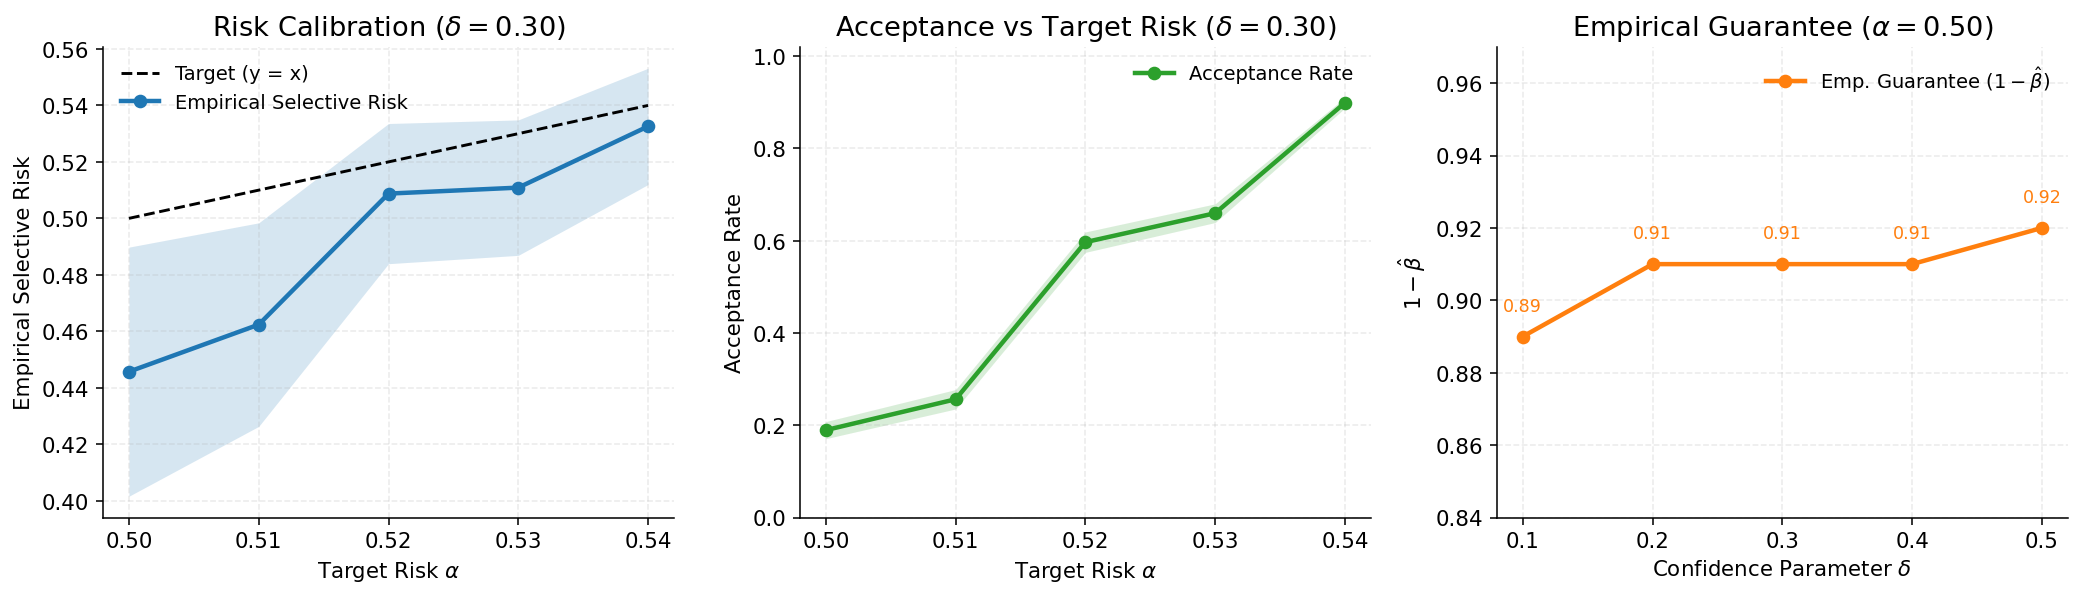

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Requires:
# table_a: fix alpha=0.50, vary delta
# columns: delta, one_minus_beta_hat
#
# table_b: fix delta=0.30, vary alpha
# columns: alpha, trial_mean_accuracy, trial_std_accuracy,
#          trial_mean_acceptance, trial_std_acceptance

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

blue = "#1f77b4"
green = "#2ca02c"
orange = "#ff7f0e"

titel_fs= 14
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# ---------------------------------------
# (1) Target Risk vs Empirical Selective Risk
# ---------------------------------------
x = table_b["alpha"].to_numpy()
emp_risk = 1.0 - table_b["trial_mean_accuracy"].to_numpy()
emp_risk_std = table_b["trial_std_accuracy"].to_numpy()  # std unchanged by (1 - acc)

x_line = np.linspace(x.min(), x.max(), 200)
axes[0].plot(x_line, x_line, "k--", lw=1.5, label="Target (y = x)")
axes[0].plot(
    x, emp_risk,
    color=blue, lw=2.3, marker="o", ms=6,
    label="Empirical Selective Risk"
)
axes[0].fill_between(
    x,
    emp_risk - emp_risk_std,
    emp_risk + emp_risk_std,
    color=blue, alpha=0.18, linewidth=0
)
axes[0].set_title(r"Risk Calibration ($\delta=0.30$)",fontsize=titel_fs)
axes[0].set_xlabel(r"Target Risk $\alpha$")
axes[0].set_ylabel("Empirical Selective Risk")
axes[0].grid(alpha=0.25, linestyle="--")
axes[0].legend(frameon=False, loc="upper left")

# ---------------------------------------
# (2) Acceptance vs Target Risk
# ---------------------------------------
acc_rate = table_b["trial_mean_acceptance"].to_numpy()
acc_rate_std = table_b["trial_std_acceptance"].to_numpy()

axes[1].plot(
    x, acc_rate,
    color=green, lw=2.3, marker="o", ms=6,
    label="Acceptance Rate"
)
axes[1].fill_between(
    x,
    acc_rate - acc_rate_std,
    acc_rate + acc_rate_std,
    color=green, alpha=0.18, linewidth=0
)
axes[1].set_title(r"Acceptance vs Target Risk ($\delta=0.30$)",fontsize=titel_fs)
axes[1].set_xlabel(r"Target Risk $\alpha$")
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_ylim(0.0, 1.02)
axes[1].grid(alpha=0.25, linestyle="--")
axes[1].legend(frameon=False, loc="best")

# ---------------------------------------
# (3) Empirical Guarantee vs Delta
# ---------------------------------------
xd = table_a["delta"].to_numpy()
yg = table_a["one_minus_beta_hat"].to_numpy()

axes[2].plot(
    xd, yg,
    color=orange, lw=2.3, marker="o", ms=6,
    label=r"Emp. Guarantee $(1-\hat{\beta})$"
)
for xi, yi in zip(xd, yg):
    axes[2].text(xi, yi + 0.006, f"{yi:.2f}", ha="center", va="bottom", fontsize=9, color=orange)

axes[2].set_title(r"Empirical Guarantee ($\alpha=0.50$)",fontsize=titel_fs)
axes[2].set_xlabel(r"Confidence Parameter $\delta$")
axes[2].set_ylabel(r"$1-\hat{\beta}$")
axes[2].set_ylim(max(0, yg.min() - 0.05), min(1.02, yg.max() + 0.05))
axes[2].grid(alpha=0.25, linestyle="--")
axes[2].legend(frameon=False, loc="best")

#fig.suptitle("Conformal Abstention: Risk, Acceptance, and Guarantee", y=1.04, fontsize=13)
plt.tight_layout()
plt.show()
